In [53]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

from sklearn.datasets import make_s_curve, make_blobs
import sklearn

import matplotlib.pyplot as plt
import plotly.express as px

from jax.example_libraries import stax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro import optim
from numpyro.infer import Predictive
from numpyro import handlers



from numpyro.contrib.einstein import RBFKernel
from CustomModules.mixture_guide_impl_source import MixtureGuidePredictive
from CustomModules.stein_impl_source import SteinVI
from CustomModules.single_site_rbf import SingleSiteRBFKernel
from CustomModules.architectures import *



from morbius import make_mobius_strip
rng_key = jax.random.key(42)

from CustomModules.normalizing_flow import normalizing_flow

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
def plot3d(d, title):
    d = d.reshape(-1, 3)
    fig = px.scatter_3d(x=d[:,0], y=d[:,1], z=d[:,2], title=title)
    fig.update_traces(marker=dict(size=2))


    fig.update_layout(
        title_text=title,
        title_x=0.5,              
        title_y=0.95,               
        title_font_family="Arial",  
        title_font_size=24,        
        title_font_color="navy",     
        margin=dict(t=60)            
    )

    fig.show()


In [55]:
import numpy as np

n_samples = 2000

X_mobius, _  = make_mobius_strip(n_samples=2000, radius = 2, width = 3, noise=0.2)

plot3d(X_mobius, "Möbius Strip")

In [56]:
X_S, t = make_s_curve(noise=0.10, random_state=0, n_samples=1000)
plot3d(X_S, "Curve Data")

In [57]:
X_blobs, _=  make_blobs(centers=2,n_features=3, cluster_std=0.5, random_state=0, n_samples=1000)
plot3d(X_blobs, "Blob Data")

# Basic VAE

In [58]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )




def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn()),
    )



In [84]:
X = X_S 

batch_size = X.shape[0]
dataloader = [X[i:i+batch_size] for i in range(0, len(X), batch_size)]

out_dim = X.reshape(X.shape[0], -1).shape[1]

hidden_dim = 8
z_dim = 2
lr=5e-3
adam = optim.Adam(lr)


encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}

In [60]:
def plot_vae(vae, rng_key, share_axis=True):
    rng_key, e_sub, d_sub, s_sub = jax.random.split(rng_key, 4)

    values = vae.encode_batch(X, e_sub)
    X_recon = vae.decode_latent({"z": values["z"]}, d_sub)

    has_m = values.get("m") is not None
    c_recon = values.get("pidx")

    plot3d(X_recon["obs"], "recon")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=share_axis, sharey=share_axis)

    for ax in axes.flat:
        ax.set_aspect('equal')

    axes[0, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_recon)
    axes[0, 0].set_title("recon latent (z)")

    if has_m:
        axes[0, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_recon)
        axes[0, 1].set_title("recon latent (m)")
    else:
        axes[0, 1].axis("off")

    values = vae.sample(s_sub, 1000)
    plot3d(values["obs"], "samples")

    c_samp = values.get("pidx")

    axes[1, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_samp)
    axes[1, 0].set_title("samples latent (z)")

    if has_m:
        axes[1, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_samp)
        axes[1, 1].set_title("samples latent (m)")
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

In [61]:
rng_key, sub_key = jax.random.split(rng_key)

base_vae = BaseVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

base_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)




100%|██████████| 10000/10000 [00:07<00:00, 1274.23it/s]


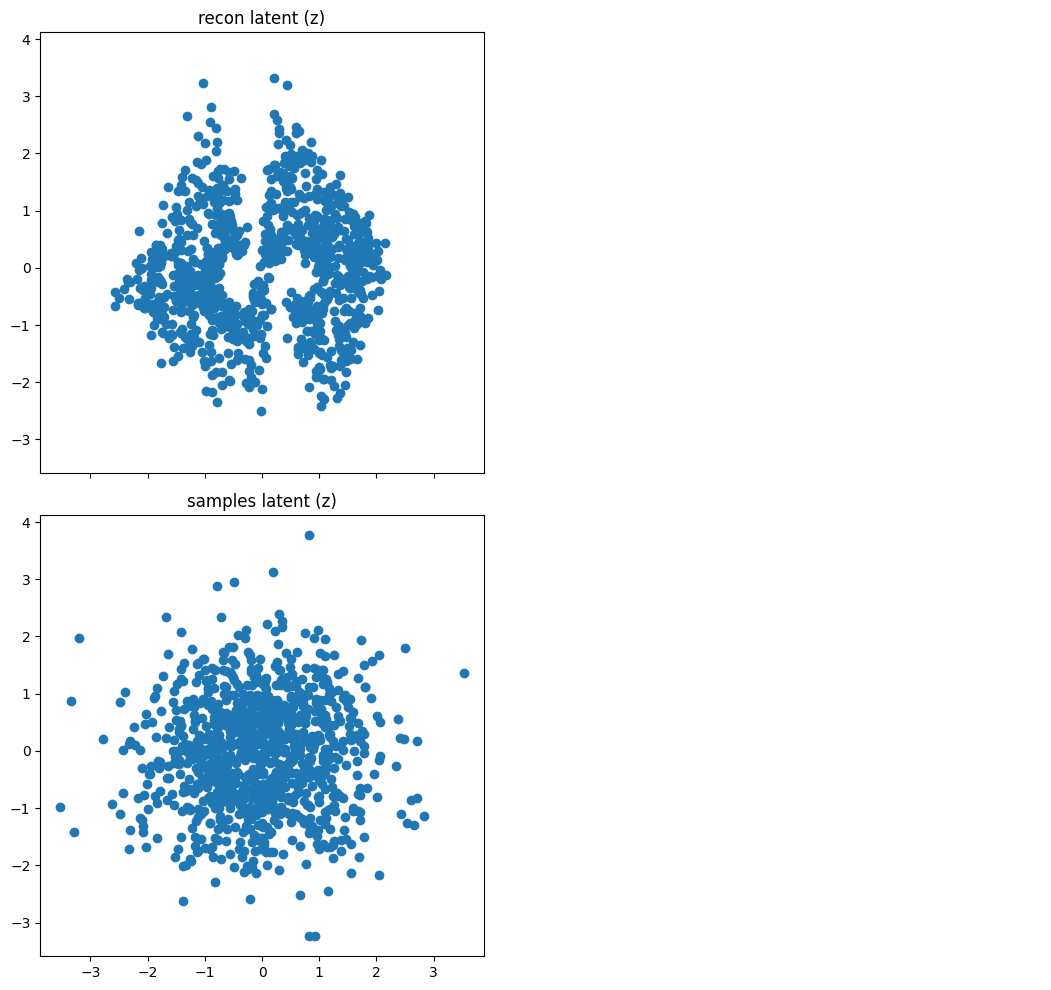

In [62]:
plot_vae(base_vae, sub_key)

# A global Parameter


In [64]:
rng_key, sub_key = jax.random.split(rng_key)

global_vae = GlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

global_vae.train(dataloader, X.shape[0], adam, 10000, sub_key)




100%|██████████| 10000/10000 [00:09<00:00, 1078.61it/s]


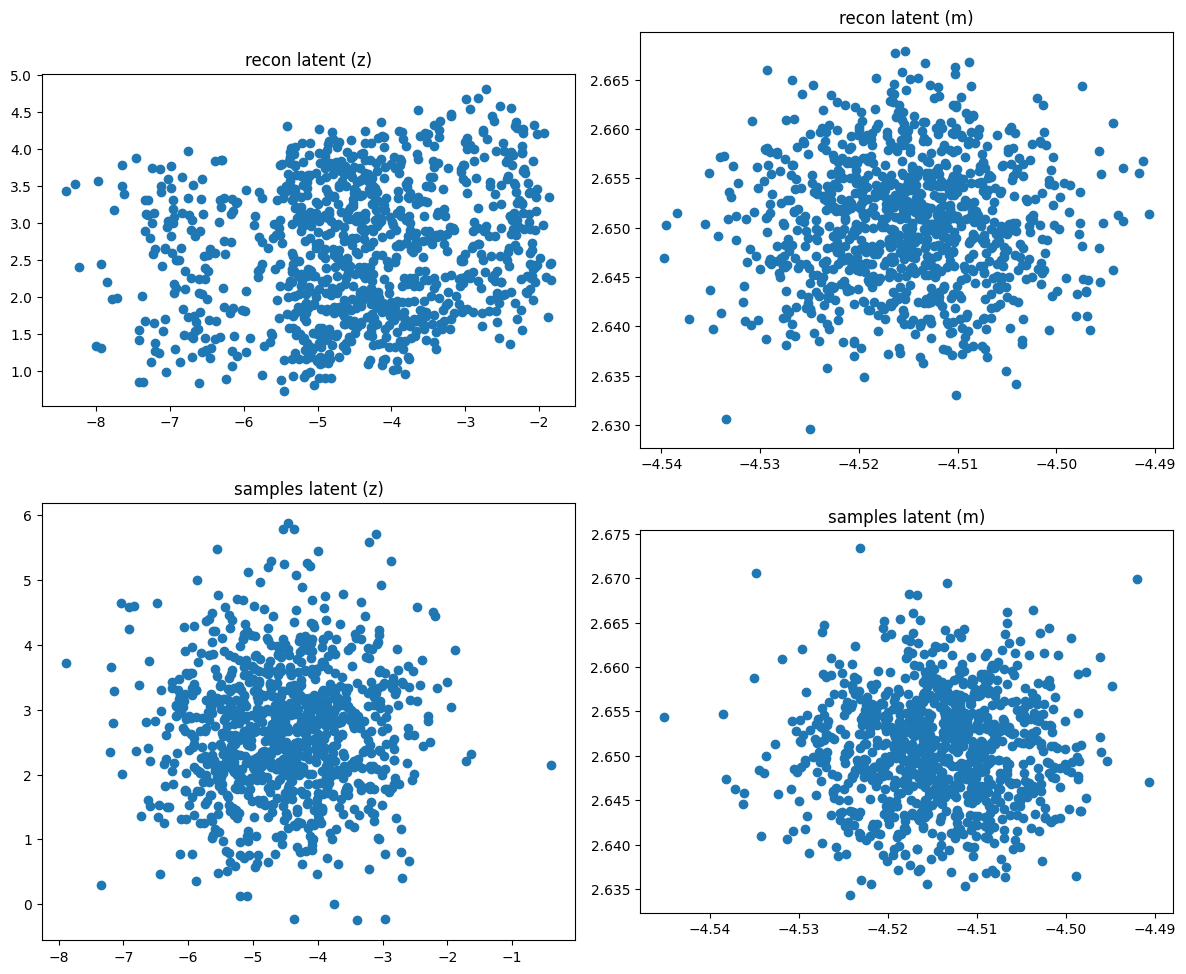

In [66]:
plot_vae(global_vae, sub_key, False)

# Stein global

In [92]:
rng_key, sub_key = jax.random.split(rng_key)

stein_global_vae = SteinGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim)

stein_global_vae.train(dataloader, X.shape[0], adam, 10000, sub_key, 5, repulsion_temperature=1)




  0%|          | 3/10000 [00:09<6:58:53,  2.51s/it] 

[-1.4409239  0.5095032] - [0.9680679 0.9678155] - Loss: 21316.0566406255625

  0%|          | 24/10000 [00:09<28:48,  5.77it/s]  

[-1.3243886   0.65903836] - [0.86280084 0.858712  ] - Loss: 17336.746093755

  1%|          | 53/10000 [00:10<09:01, 18.38it/s]

...

 16%|█▌        | 1576/10000 [00:27<01:41, 82.92it/s]

[-3.0765376  2.9660156] - [0.21415715 0.24575429] - Loss: 152.82826232910156

 23%|██▎       | 2283/10000 [00:24<01:22, 94.01it/s]

[-3.080806   2.9669385] - [0.21340562 0.24547432] - Loss: 96.982307434082032

KeyboardInterrupt: 

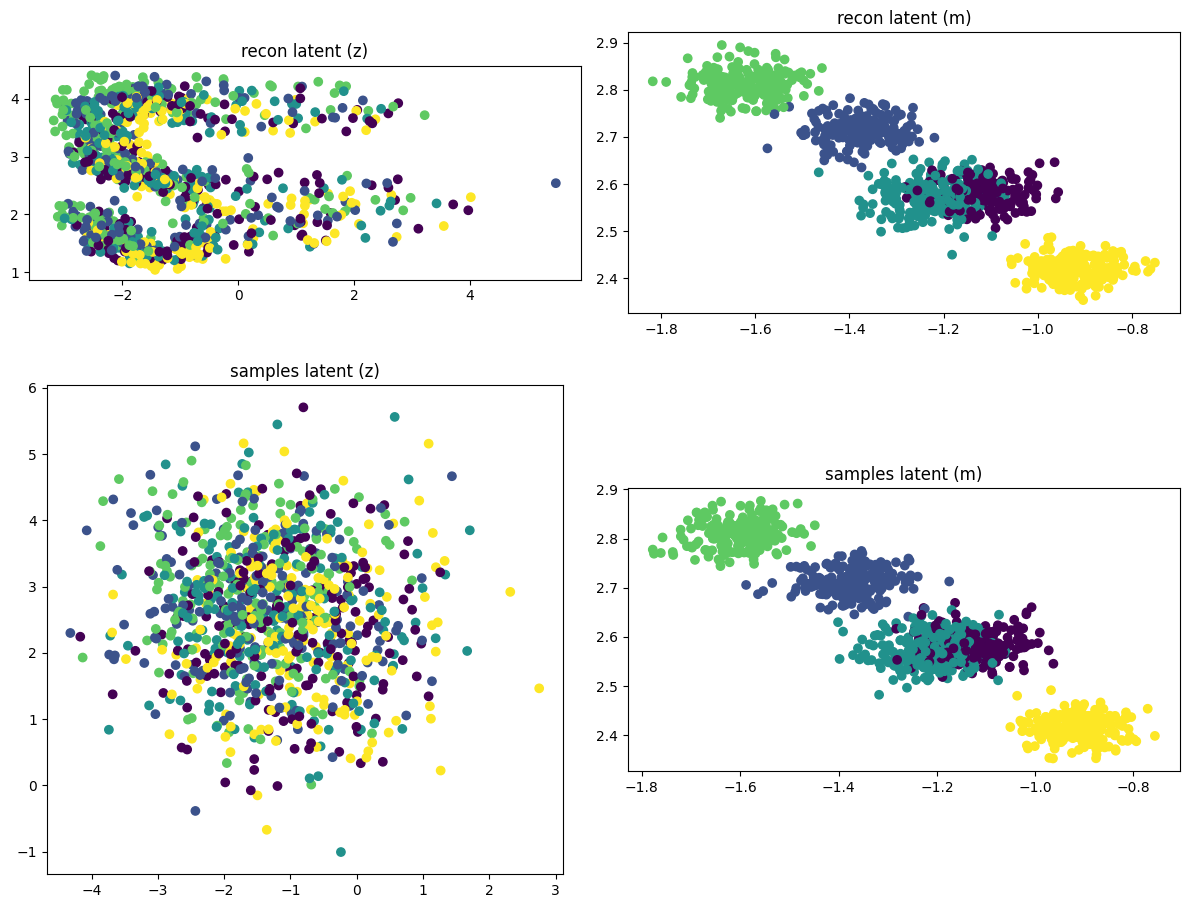

In [74]:
plot_vae(stein_global_vae, sub_key, False)

# Guide Flow


In [75]:
rng_key, sub_key = jax.random.split(rng_key)


flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 5, "inv": False}

guide_flow_vae = GuideFlowGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

guide_flow_vae.train(dataloader, X.shape[0], adam, 5000, sub_key)



100%|██████████| 5000/5000 [00:18<00:00, 267.63it/s]


In [77]:
guide_flow_vae.params

{'B': Array([nan, nan], dtype=float32),
 'a': Array([nan, nan], dtype=float32),
 'decoder$params': [(Array([[nan, nan, nan, nan, nan, nan, nan, nan],
          [nan, nan, nan, nan, nan, nan, nan, nan],
          [nan, nan, nan, nan, nan, nan, nan, nan],
          [nan, nan, nan, nan, nan, nan, nan, nan]], dtype=float32),
   Array([nan, nan, nan, nan, nan, nan, nan, nan], dtype=float32)),
  (),
  (Array([[nan, nan, nan, nan, nan, nan, nan, nan],
          [nan, nan, nan, nan, nan, nan, nan, nan],
          [nan, nan, nan, nan, nan, nan, nan, nan],
          [nan, nan, nan, nan, nan, nan, nan, nan],
          [nan, nan, nan, nan, nan, nan, nan, nan],
          [nan, nan, nan, nan, nan, nan, nan, nan],
          [nan, nan, nan, nan, nan, nan, nan, nan],
          [nan, nan, nan, nan, nan, nan, nan, nan]], dtype=float32),
   Array([nan, nan, nan, nan, nan, nan, nan, nan], dtype=float32)),
  (),
  (Array([[nan, nan, nan],
          [nan, nan, nan],
          [nan, nan, nan],
          [nan,

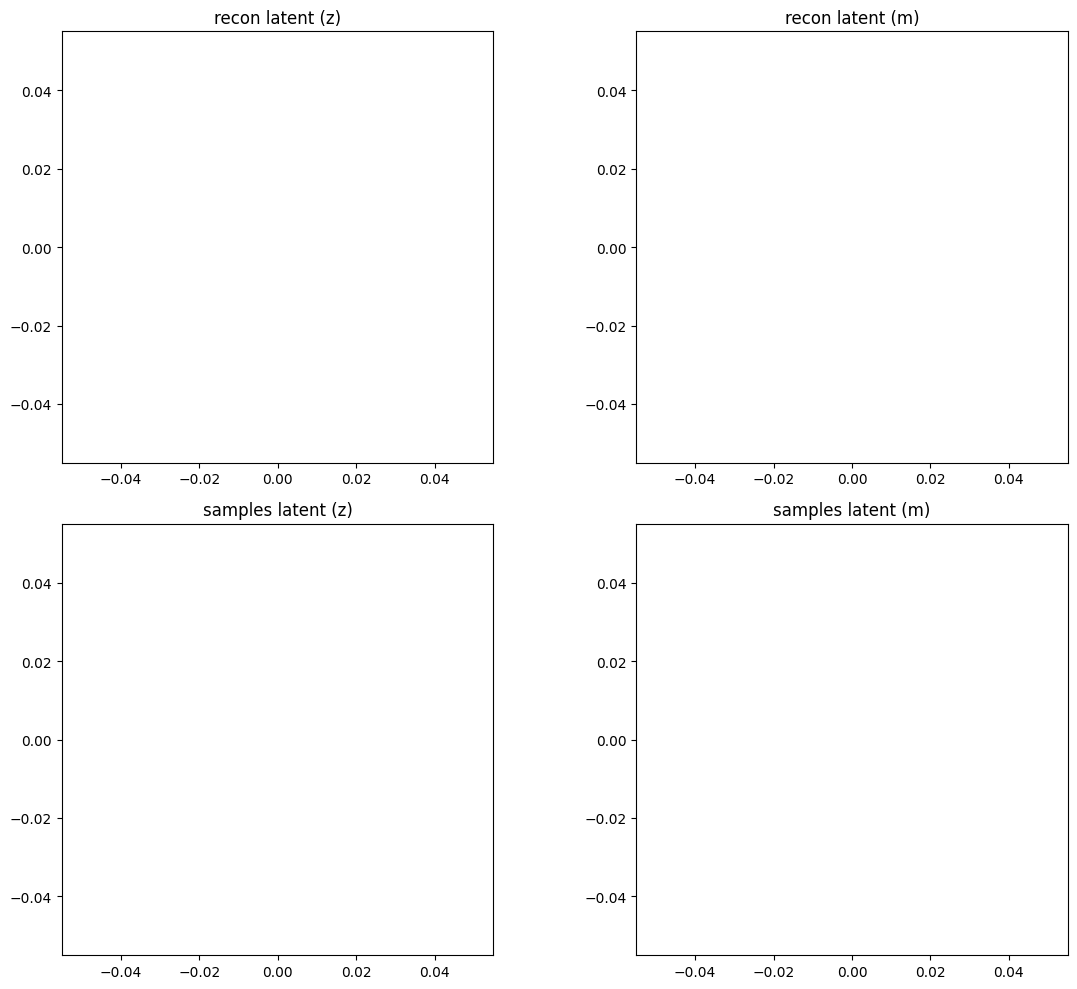

In [76]:
plot_vae(guide_flow_vae, sub_key, False)

# STEIN GUIDE FLOW

In [109]:
rng_key, sub_key = jax.random.split(rng_key)
clipped_adam = optim.ClippedAdam(lr, 10)

flow_args = {"input_dim": z_dim, "hidden_dims": [2, 2], "steps": 5, "inv": True}

stein_guide_flow_vae = SteinGuideFlowVAE(encoder, encoder_args, decoder, decoder_args, z_dim, flow=normalizing_flow, flow_args=flow_args)

stein_guide_flow_vae.train(dataloader, X.shape[0], adam, 10000, sub_key, num_stein_particles=3, repulsion_temperature=1)



Epoch 9975, Loss: 6.26: 100%|██████████| 10000/10000 [01:32<00:00, 108.58it/s] 


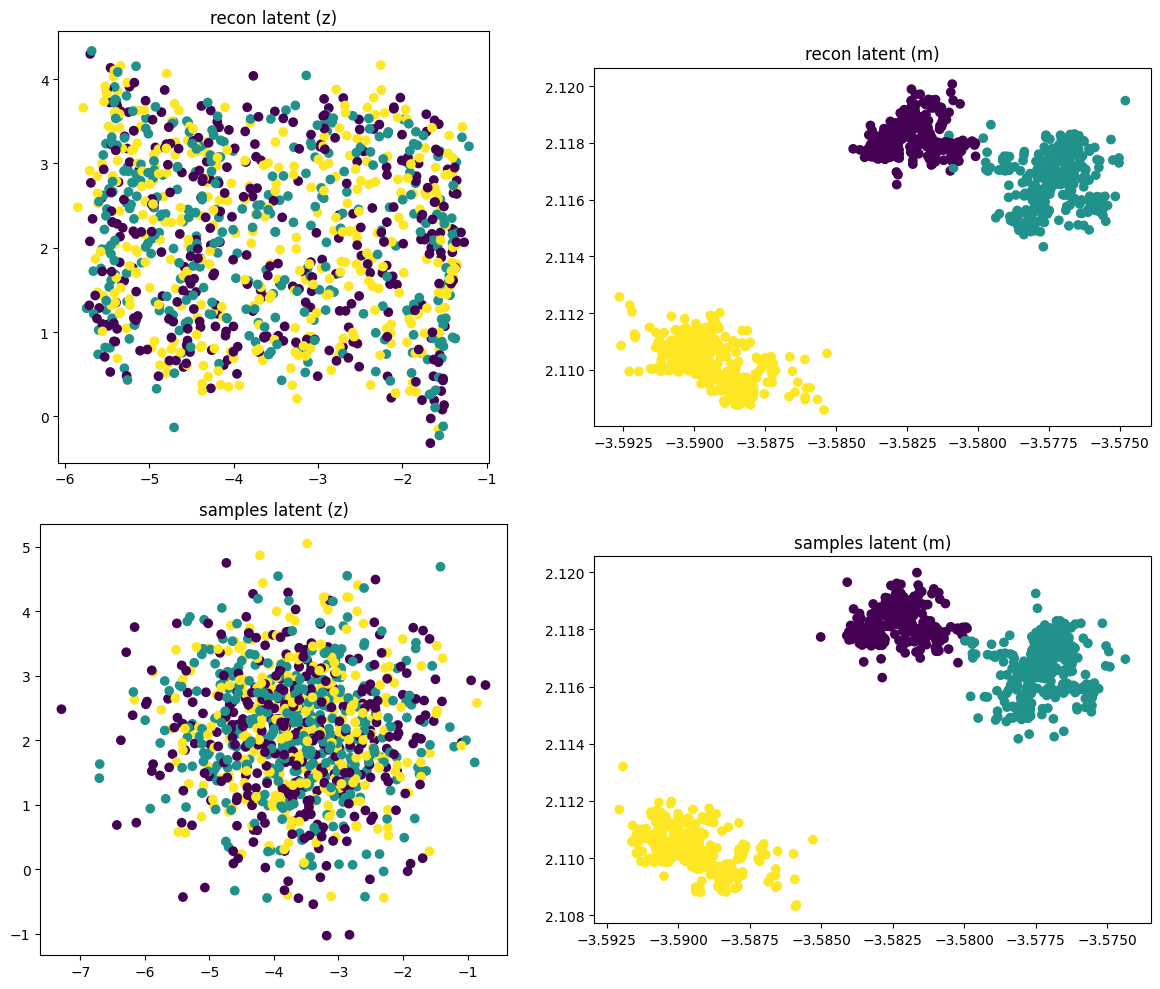

In [110]:
plot_vae(stein_guide_flow_vae, sub_key, False)